In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [4]:
df = pd.read_csv("../data/processed/bundesliga_features.csv")

print("Shape:", df.shape)
df.head()

Shape: (4896, 35)


,Date,HomeTeam,AwayTeam,home_points_avg,away_points_avg,home_goals_avg,away_goals_avg,home_conceded_avg,away_conceded_avg,home_wins,...,home_home_games,away_away_games,FTR,home_elo,away_elo,elo_difference,points_avg_diff,goals_avg_diff,conceded_avg_diff,wins_diff
0,2010-08-20,Bayern Munich,Wolfsburg,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0,0,H,1500.0,1500.0,0.0,0.0,0.0,0.0,0
1,2010-08-21,FC Koln,Kaiserslautern,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0,0,A,1500.0,1500.0,0.0,0.0,0.0,0.0,0
2,2010-08-21,Freiburg,St Pauli,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0,0,A,1500.0,1500.0,0.0,0.0,0.0,0.0,0
3,2010-08-21,Hamburg,Schalke 04,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0,0,H,1500.0,1500.0,0.0,0.0,0.0,0.0,0
4,2010-08-21,Hannover,Ein Frankfurt,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0,0,H,1500.0,1500.0,0.0,0.0,0.0,0.0,0


In [5]:
df.columns.tolist()

['Date',
 'HomeTeam',
 'AwayTeam',
 'home_points_avg',
 'away_points_avg',
 'home_goals_avg',
 'away_goals_avg',
 'home_conceded_avg',
 'away_conceded_avg',
 'home_wins',
 'away_wins',
 'home_draws',
 'away_draws',
 'home_losses',
 'away_losses',
 'home_games_history',
 'away_games_history',
 'home_home_points_avg',
 'away_away_points_avg',
 'home_home_goals_avg',
 'away_away_goals_avg',
 'home_home_conceded_avg',
 'away_away_conceded_avg',
 'home_home_wins',
 'away_away_wins',
 'home_home_games',
 'away_away_games',
 'FTR',
 'home_elo',
 'away_elo',
 'elo_difference',
 'points_avg_diff',
 'goals_avg_diff',
 'conceded_avg_diff',
 'wins_diff']

In [6]:
y = df["FTR"]

In [7]:
feature_columns = [
    "home_points_avg",
    "away_points_avg",

    "home_goals_avg",
    "away_goals_avg",

    "home_conceded_avg",
    "away_conceded_avg",

    "home_wins",
    "away_wins",

    "home_draws",
    "away_draws",

    "home_losses",
    "away_losses",

    "home_games_history",
    "away_games_history",

    "home_home_points_avg",
    "away_away_points_avg",

    "home_home_goals_avg",
    "away_away_goals_avg",

    "home_home_conceded_avg",
    "away_away_conceded_avg",

    "home_home_wins",
    "away_away_wins",

    "home_home_games",
    "away_away_games",

    "home_elo",
    "away_elo",
    "elo_difference",

    "points_avg_diff",
    "goals_avg_diff",
    "conceded_avg_diff",
    "wins_diff"
]

In [8]:
X = df[feature_columns]

In [9]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (4896, 31)
Target: (4896,)


In [10]:
X.head()

,home_points_avg,away_points_avg,home_goals_avg,away_goals_avg,home_conceded_avg,away_conceded_avg,home_wins,away_wins,home_draws,away_draws,...,away_away_wins,home_home_games,away_away_games,home_elo,away_elo,elo_difference,points_avg_diff,goals_avg_diff,conceded_avg_diff,wins_diff
0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,0,0,0,1500.0,1500.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,0,0,0,1500.0,1500.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,0,0,0,1500.0,1500.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,0,0,0,1500.0,1500.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,0,0,0,1500.0,1500.0,0.0,0.0,0.0,0.0,0


In [11]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (3916, 31)
Test: (980, 31)


## Baseline

Als Referenz verwenden wir eine einfache Strategie, die immer einen
Heimsieg vorhersagt.

Ein Machine-Learning-Modell sollte diese einfache Strategie zumindest
übertreffen, um einen Mehrwert zu zeigen.

In [12]:
baseline_predictions = np.full(len(y_test), "H")

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.4245


## Logistic Regression

Logistic Regression dient als einfaches und gut interpretierbares
Baseline-Modell für die eigentliche Machine-Learning-Vorhersage.

Da unsere Features unterschiedliche Größenordnungen besitzen, werden
sie vor dem Training standardisiert.

In [13]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['A','D','H']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['home_points_avg','away_points_avg','home_goals_avg',...,'goals_avg_diff', 'conceded_avg_diff','wins_diff']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [14]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5102


In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.49      0.51      0.50       314
           D       0.00      0.00      0.00       250
           H       0.52      0.82      0.64       416

    accuracy                           0.51       980
   macro avg       0.34      0.44      0.38       980
weighted avg       0.38      0.51      0.43       980



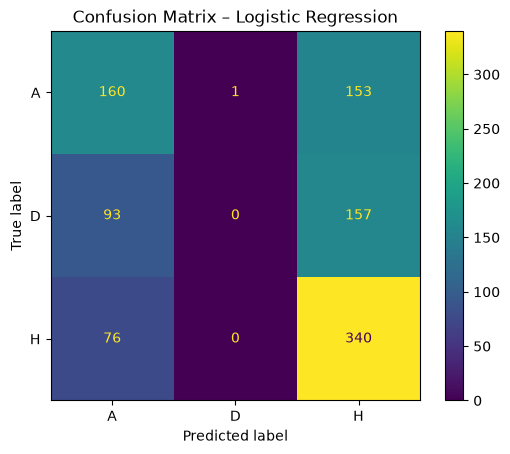

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=model.classes_
)

plt.title("Confusion Matrix – Logistic Regression")
plt.show()

In [17]:
probabilities = model.predict_proba(X_test)

In [18]:
print(model.classes_)

['A' 'D' 'H']


In [19]:
probability_df = pd.DataFrame(
    probabilities,
    columns=model.classes_
)

probability_df.head(10)

,A,D,H
0,0.246022,0.242343,0.511635
1,0.657327,0.172525,0.170149
2,0.398828,0.269524,0.331648
3,0.057666,0.163217,0.779117
4,0.145310,0.245987,0.608703
5,0.433743,0.246658,0.319599
6,0.121209,0.238183,0.640609
7,0.404292,0.254599,0.341109
8,0.231289,0.290781,0.477930
9,0.294808,0.264926,0.440266


In [20]:
model_log_loss = log_loss(
    y_test,
    probabilities,
    labels=model.classes_
)

print(f"Log Loss: {model_log_loss:.4f}")

Log Loss: 0.9888


In [21]:
results = []

results.append({
    "Model": "Logistic Regression + Elo",
    "Accuracy": accuracy,
    "Log Loss": model_log_loss
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Log Loss
0,Logistic Regression + Elo,0.510204,0.988779


## XGBoost

XGBoost wird als nichtlineares Vergleichsmodell verwendet.

Dadurch können wir untersuchen, ob komplexere Beziehungen zwischen
den Features zu besseren Vorhersagen führen als das lineare Modell.

In [22]:
from xgboost import XGBClassifier

In [23]:
label_mapping = {
    "A": 0,
    "D": 1,
    "H": 2
}

y_train_xgb = y_train.map(label_mapping)
y_test_xgb = y_test.map(label_mapping)

In [24]:
print(y_train_xgb.value_counts())

FTR
2    1772
0    1197
1     947
Name: count, dtype: int64


In [25]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

In [26]:
xgb_model.fit(
    X_train,
    y_train_xgb
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) r

In [27]:
y_pred_xgb = xgb_model.predict(X_test)

In [28]:
inverse_mapping = {
    0: "A",
    1: "D",
    2: "H"
}

y_pred_xgb_labels = pd.Series(y_pred_xgb).map(inverse_mapping)

In [29]:
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb_labels
)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

XGBoost Accuracy: 0.4918


In [30]:
print(
    classification_report(
        y_test,
        y_pred_xgb_labels,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.49      0.48      0.49       314
           D       0.22      0.04      0.07       250
           H       0.52      0.77      0.62       416

    accuracy                           0.49       980
   macro avg       0.41      0.43      0.39       980
weighted avg       0.43      0.49      0.44       980



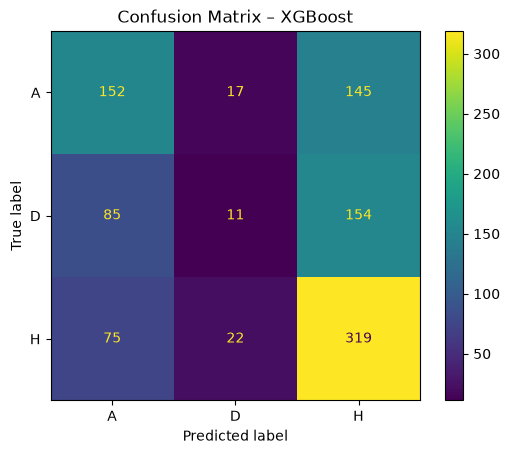

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_labels,
    labels=["A", "D", "H"],
    display_labels=["A", "D", "H"]
)

plt.title("Confusion Matrix – XGBoost")
plt.show()

In [32]:
xgb_probabilities = xgb_model.predict_proba(X_test)

In [33]:
xgb_probability_df = pd.DataFrame(
    xgb_probabilities,
    columns=["A", "D", "H"]
)

xgb_probability_df.head(10)

,A,D,H
0,0.268058,0.347058,0.384883
1,0.644190,0.178546,0.177264
2,0.553340,0.238968,0.207693
3,0.035185,0.047142,0.917673
4,0.086761,0.159069,0.754170
5,0.519095,0.192161,0.288744
6,0.104915,0.134942,0.760144
7,0.342556,0.312286,0.345158
8,0.331418,0.184091,0.484491
9,0.400584,0.254480,0.344935


In [34]:
xgb_log_loss = log_loss(
    y_test,
    xgb_probabilities,
    labels=["A", "D", "H"]
)

print(f"XGBoost Log Loss: {xgb_log_loss:.4f}")

XGBoost Log Loss: 1.0324


In [35]:
results = []

results.append({
    "Model": "Logistic Regression + Elo",
    "Accuracy": accuracy,
    "Log Loss": model_log_loss
})

In [36]:
results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Log Loss": xgb_log_loss
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Log Loss
0,Logistic Regression + Elo,0.510204,0.988779
1,XGBoost,0.491837,1.032446


## Hyperparameter Tuning

Die XGBoost-Hyperparameter werden nicht anhand des finalen Testsets
optimiert.

Stattdessen wird eine zeitbasierte Validierung innerhalb des
Trainingszeitraums verwendet.

In [37]:
from sklearn.model_selection import TimeSeriesSplit

In [38]:
tscv = TimeSeriesSplit(n_splits=5)

In [39]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1],
    "min_child_weight": [1, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

In [40]:
from itertools import product

In [41]:
param_names = list(param_grid.keys())

param_combinations = list(
    product(*param_grid.values())
)

print("Anzahl Kombinationen:", len(param_combinations))

Anzahl Kombinationen: 24


In [42]:
tuning_results = []

for combination in param_combinations:

    params = dict(zip(param_names, combination))

    fold_log_losses = []
    fold_accuracies = []

    for train_idx, val_idx in tscv.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        # XGBoost benötigt numerische Labels
        y_fold_train_xgb = y_fold_train.map(label_mapping)
        y_fold_val_xgb = y_fold_val.map(label_mapping)

        model = XGBClassifier(
            **params,
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=42
        )

        model.fit(
            X_fold_train,
            y_fold_train_xgb
        )

        probabilities = model.predict_proba(X_fold_val)

        predictions = model.predict(X_fold_val)

        fold_log_loss = log_loss(
            y_fold_val_xgb,
            probabilities,
            labels=[0, 1, 2]
        )

        fold_accuracy = accuracy_score(
            y_fold_val_xgb,
            predictions
        )

        fold_log_losses.append(fold_log_loss)
        fold_accuracies.append(fold_accuracy)

    tuning_results.append({
        **params,
        "mean_log_loss": np.mean(fold_log_losses),
        "mean_accuracy": np.mean(fold_accuracies)
    })

In [43]:
tuning_df = pd.DataFrame(tuning_results)

In [44]:
tuning_df.sort_values(
    "mean_log_loss"
).head(10)

,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,mean_log_loss,mean_accuracy
1,200,2,0.05,5,0.8,0.8,1.018062,0.499693
0,200,2,0.05,1,0.8,0.8,1.018601,0.499693
5,200,3,0.05,5,0.8,0.8,1.035986,0.498773
4,200,3,0.05,1,0.8,0.8,1.037888,0.488650
13,400,2,0.05,5,0.8,0.8,1.037910,0.491718
12,400,2,0.05,1,0.8,0.8,1.037972,0.491411
3,200,2,0.10,5,0.8,0.8,1.042882,0.493558
2,200,2,0.10,1,0.8,0.8,1.043877,0.488957
9,200,4,0.05,5,0.8,0.8,1.051452,0.490798
8,200,4,0.05,1,0.8,0.8,1.055025,0.485890


In [45]:
best_params = (
    tuning_df
    .sort_values("mean_log_loss")
    .iloc[0]
)

best_params

n_estimators        200.000000
max_depth             2.000000
learning_rate         0.050000
min_child_weight      5.000000
subsample             0.800000
colsample_bytree      0.800000
mean_log_loss         1.018062
mean_accuracy         0.499693
Name: 1, dtype: float64

In [46]:
best_xgb = XGBClassifier(
    n_estimators=int(best_params["n_estimators"]),
    max_depth=int(best_params["max_depth"]),
    learning_rate=float(best_params["learning_rate"]),
    min_child_weight=int(best_params["min_child_weight"]),
    subsample=float(best_params["subsample"]),
    colsample_bytree=float(best_params["colsample_bytree"]),
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

In [47]:
best_xgb.fit(
    X_train,
    y_train.map(label_mapping)
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) r

In [48]:
final_probabilities = best_xgb.predict_proba(X_test)

final_predictions = best_xgb.predict(X_test)

In [49]:
final_accuracy = accuracy_score(
    y_test.map(label_mapping),
    final_predictions
)

print(f"Final XGBoost Accuracy: {final_accuracy:.4f}")

Final XGBoost Accuracy: 0.5092


In [50]:
final_log_loss = log_loss(
    y_test.map(label_mapping),
    final_probabilities,
    labels=[0, 1, 2]
)

print(f"Final XGBoost Log Loss: {final_log_loss:.4f}")

Final XGBoost Log Loss: 0.9988


In [51]:
inverse_mapping = {
    0: "A",
    1: "D",
    2: "H"
}

final_predictions_labels = pd.Series(
    final_predictions
).map(inverse_mapping)

In [52]:
print(
    classification_report(
        y_test,
        final_predictions_labels,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.50      0.51      0.50       314
           D       0.00      0.00      0.00       250
           H       0.52      0.82      0.63       416

    accuracy                           0.51       980
   macro avg       0.34      0.44      0.38       980
weighted avg       0.38      0.51      0.43       980



In [53]:
final_results = pd.DataFrame([
    {
        "Model": "Logistic Regression + Elo",
        "Accuracy": accuracy,
        "Log Loss": model_log_loss
    },
    {
        "Model": "XGBoost Baseline",
        "Accuracy": xgb_accuracy,
        "Log Loss": xgb_log_loss
    },
    {
        "Model": "XGBoost Tuned",
        "Accuracy": final_accuracy,
        "Log Loss": final_log_loss
    }
])

final_results

,Model,Accuracy,Log Loss
0,Logistic Regression + Elo,0.510204,0.988779
1,XGBoost Baseline,0.491837,1.032446
2,XGBoost Tuned,0.509184,0.998755


## FÜR GUI

Es werden die Daten von Logistic Regression + Elo im folgenden genutzt, da sie die besten Ergebnisse aufweisen

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

# Finales Logistic-Regression-Modell
logistic_model_final = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=2000))
])

logistic_model_final.fit(
    X_train,
    y_train
)

print("Klassen:", logistic_model_final.classes_)

Klassen: ['A' 'D' 'H']


In [58]:
joblib.dump(
    logistic_model_final,
    "../models/logistic_regression_elo.pkl"
)

joblib.dump(
    feature_columns,
    "../models/feature_columns.pkl"
)

print("Modell erfolgreich gespeichert.")

Modell erfolgreich gespeichert.


In [59]:
loaded_model = joblib.load(
    "../models/logistic_regression_elo.pkl"
)

print(type(loaded_model))
print(loaded_model.classes_)

<class 'sklearn.pipeline.Pipeline'>
['A' 'D' 'H']
